In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("bank.csv", sep = ";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df.select_dtypes(include = 'object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [8]:
le = LabelEncoder()

In [9]:
for col in df.select_dtypes(include = 'object').columns:
    df[col] = le.fit_transform(df[col])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  int64
 2   marital    45211 non-null  int64
 3   education  45211 non-null  int64
 4   default    45211 non-null  int64
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  int64
 7   loan       45211 non-null  int64
 8   contact    45211 non-null  int64
 9   day        45211 non-null  int64
 10  month      45211 non-null  int64
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  int64
 16  y          45211 non-null  int64
dtypes: int64(17)
memory usage: 5.9 MB


In [11]:
X = df.drop('y', axis = 1)
y = df['y']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
df['y'].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

[]

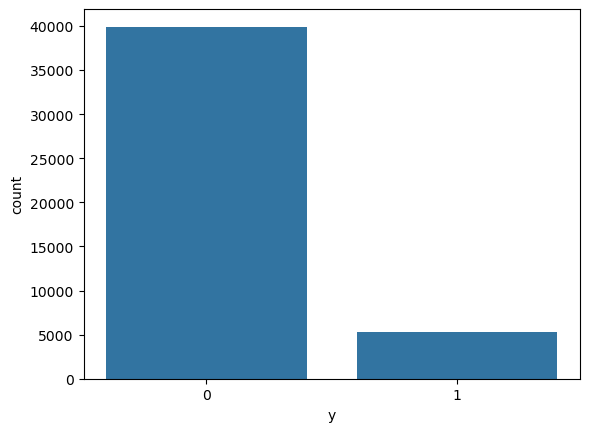

In [14]:
sns.countplot(x = 'y', data = df)
plt.plot()

[]

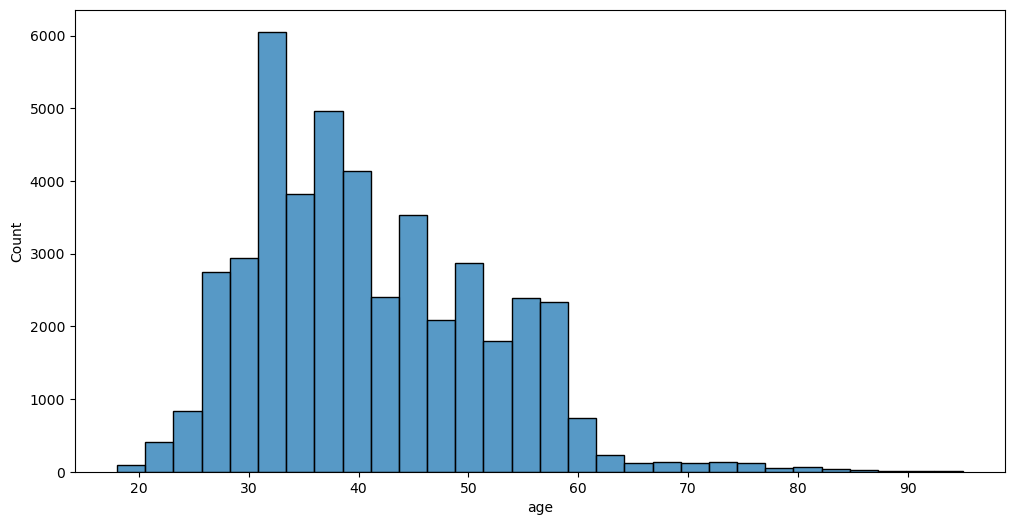

In [15]:
plt.figure(figsize = (12, 6))
sns.histplot(df['age'], bins = 30)
plt.plot()

[]

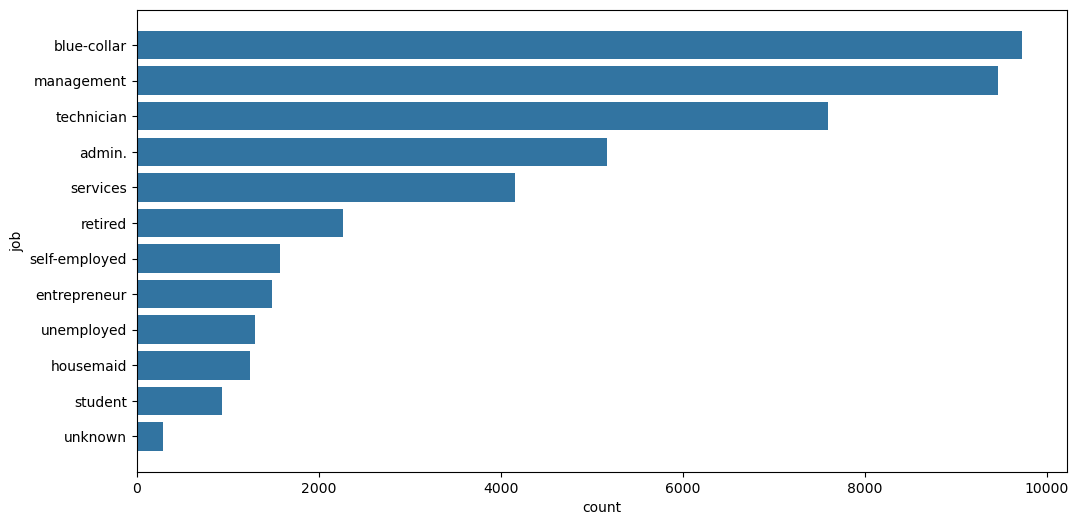

In [16]:
plt.figure(figsize = (12, 6))
sns.countplot(
    y = 'job',
    data = pd.read_csv('bank.csv', sep = ';'),
    order = pd.read_csv('bank.csv', sep = ';')['job'].value_counts().index
)
plt.plot()

[]

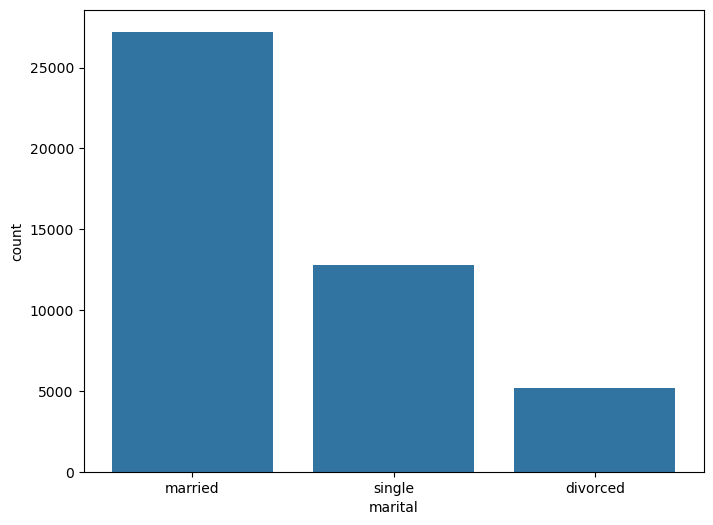

In [17]:
plt.figure(figsize = (8, 6))
sns.countplot(
    x = 'marital',
    data = pd.read_csv("bank.csv", sep = ';')
)
plt.plot()

[]

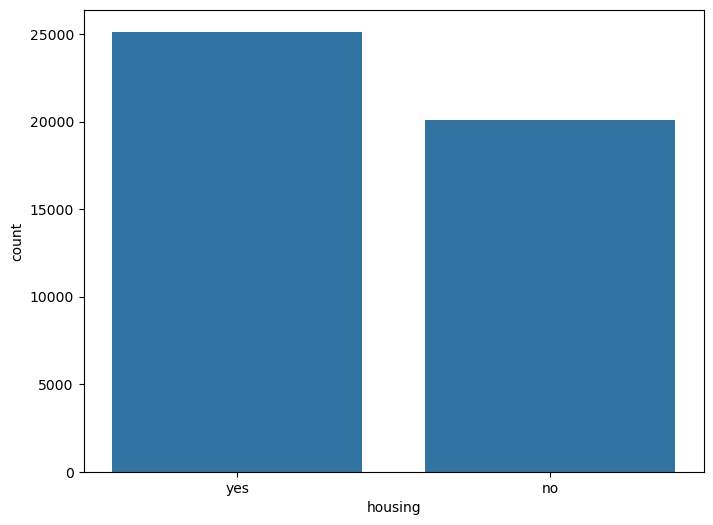

In [18]:
plt.figure(figsize = (8, 6))
sns.countplot(
    x = 'housing',
    data = pd.read_csv("bank.csv", sep=';')
)
plt.plot()

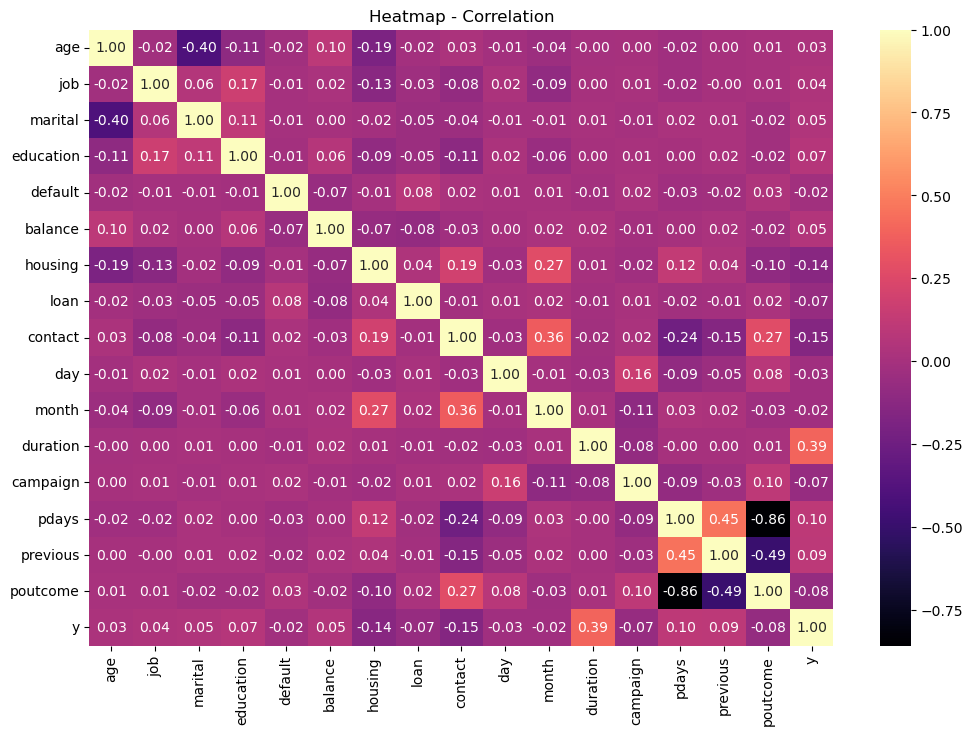

In [19]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='magma'
)
plt.title("Heatmap - Correlation")
plt.show()

In [20]:
model = DecisionTreeClassifier(
    criterion = "entropy",
    random_state = 42
)

In [21]:
model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred = model.predict(X_test)

[]

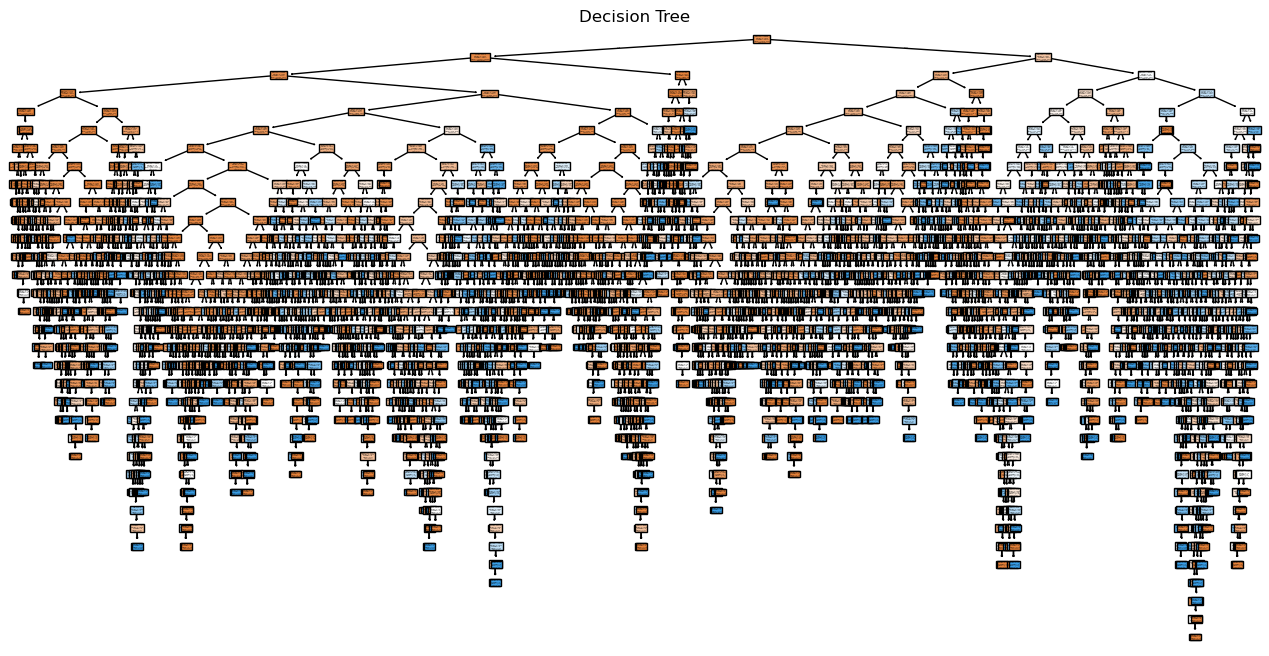

In [23]:
plt.figure(figsize = (16, 8))
tree.plot_tree(
    model, 
    feature_names = X.columns,
    class_names = ['No', 'Yes'],
    filled = True
)
plt.title("Decision Tree")
plt.plot()

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"{accuracy: .2f}")

 0.88


In [25]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7389  563]
 [ 560  531]]


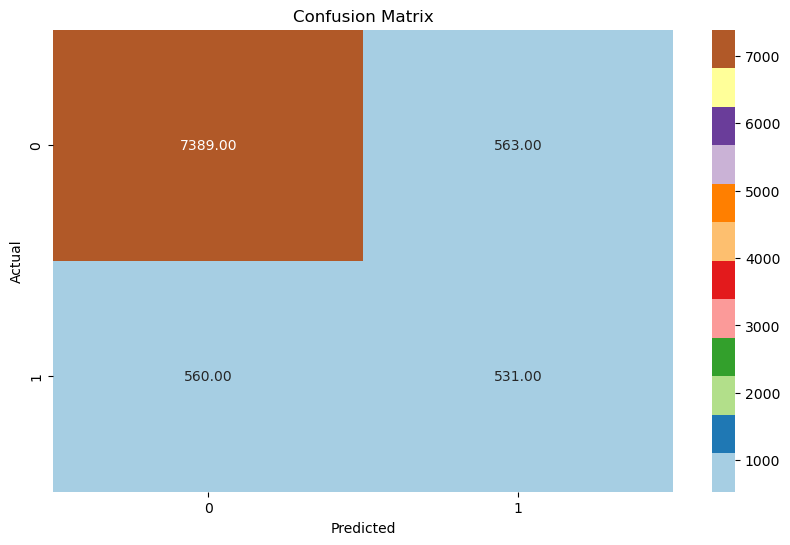

In [26]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Paired'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.49      0.49      0.49      1091

    accuracy                           0.88      9043
   macro avg       0.71      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



#

#

#

#

#

#

#

#

#

#

#

#

#

#

#

#

#

#

#